In [1]:
#to test how the energy varies over different network architectures
#4 rusn default
#4 runs defualt with mc dropout before the last layer
#4 runs trained with outlier exposure
#4 runs trained with small affine augmentation around 30 degres in both directions
#4 runs with pixmix
#4 model trained on 50 untransformed plus 50 transformed samples per class. Take train_loader and train_loader_transformed and make a new loader

In [2]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from its.search import InverseTransformationSearch
from search.parallel_gradient import ParallelGradientDescent
from utils.affine_transforms_old import AffineTransformation2D
from utils.sampling import BatchNegativeSampler

#torch.cuda.is_available = lambda: False
#device = torch.device("cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#look for experiment files in parents
import os

path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)

experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")
dataset = "bigger_mnist"

default_architecutre_mapping = {
    "mnist":"resnet_small",
    "bigger_mnist":"resnet_small",
    "emnist": "extended_resnet_small",
    "bigger_emnist":"bigger_extended_resnet_small",
    "coil100":"coil_resnet_small",
    "tu_berlin":"bi_lstm",
    "modelnet10":"pointnetplus",
}



architecture = default_architecutre_mapping[dataset]
budget = None

In [3]:
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info,get_dataset

dataset_info = get_dataset_info(dataset)

dataset_dict = get_dataset(dataset_info,path=experiment_files_path_data, batch_size=dataset_info.batch_size)
transform_name = dataset_info.transform_seq_name

In [4]:


dataset_dict.keys()
dataset_train = dataset_dict['train_dataset']
dataset_val = dataset_dict['val_dataset']
dataset_test = dataset_dict['test_dataset']
train_loader = dataset_dict['train_loader']
val_loader = dataset_dict['val_loader']
test_loader = dataset_dict['test_loader']
n_classes = dataset_info.num_classes
train_loader_transformed = dataset_dict['train_loader_transformed']
val_loader_transformed = dataset_dict['val_loader_transformed']
test_loader_transformed = dataset_dict['test_loader_transformed']
train_loader_no_shuffle = dataset_dict['train_loader_no_shuffle']

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


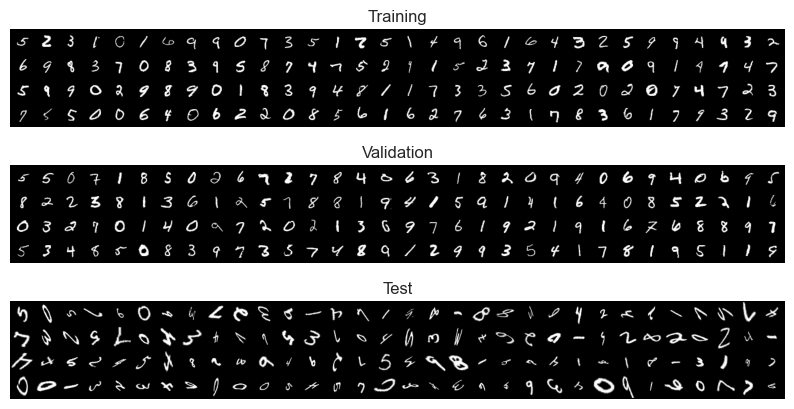

In [5]:
x = next(iter(test_loader_transformed))[0]

batch_size = next(iter(train_loader))[0].shape[0]

from utils.eval.vis import vis_dataset

vis_dataset(train_loader, val_loader, test_loader_transformed)
from experiment_thesis.main import train_and_get_model, train_or_load_energy_model
from experiment_thesis.dataset_preperation.basic_networks import get_network
from utils.eval.main_model import evaluate_base_model

model_dir_path = os.path.join(current_path, "experiment_files", "models")
embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")
# Add results dir and helper for save paths
results_dir_path = os.path.join(current_path, "experiment_files", "results", dataset, architecture,
                                "unsupervised_metrics")
os.makedirs(results_dir_path, exist_ok=True)


def savepath(label: str) -> str:
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(results_dir_path, transform_name, f"{safe}.json")

In [6]:
#chek if data is iamge data
is_image_data = len(dataset_info.input_size) == 3 and dataset_info.input_size[0] in [1, 3]
from utils.transforms.apply import grid_resample
from experiment_thesis.dataset_preperation.transformation import get_transformation_sequence_images

transform_seq = get_transformation_sequence_images(
    name=dataset_info.transform_seq_name,
    resample_method=dataset_info.resample_method,
    init_method="sobol"
).to(device)

In [7]:
runs=4
run =0

In [8]:
model = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train= f"{dataset}_{architecture}_embedding_cache_train_run" +str(run)

train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs,
        "precision": "16-mixed",
},load_if_exists=True)
model = model.to(device).eval()
from experiment_thesis.dataset_preperation.basic_networks import make_deterministic
make_deterministic(model)

#check main model
res = evaluate_base_model(model, test_loader_transformed, device)
print(res)
res = evaluate_base_model(model, test_loader, device)
print(res)



Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small.safetensors


{'accuracy': 0.3612000048160553, 'f2_macro': 0.358009397983551, 'f2_micro': 0.3612000048160553, 'f2_weighted': 0.35620489716529846}


{'accuracy': 0.9941999912261963, 'f2_macro': 0.9941785931587219, 'f2_micro': 0.9941999912261963, 'f2_weighted': 0.9941990375518799}


In [9]:
from experiment_thesis.dataset_preperation.get_dataset import get_layer_embedding_cache_config,create_layer_embedding_cache
cache_config = get_layer_embedding_cache_config(dataset, architecture,transform_name=None,dataset_info=dataset_info)
train_cache =create_layer_embedding_cache(model, train_loader_no_shuffle,cache_config, embedding_cache_path, device=device)

In [10]:
from experiment_thesis.ood.base_prepare import create_ood_problem, get_default_ood_params

energy_problem = create_ood_problem(
            detector_name="energy",
            params=get_default_ood_params("energy"),
            model=model,
            train_cache=train_cache,
            transform_seq=transform_seq,
            dataset_info=dataset_info,
            architecture=architecture,
            device=str(device),
    )

entropy_problem = create_ood_problem(
            detector_name="entropy",
            params=get_default_ood_params("entropy"),
            model=model,
            train_cache=train_cache,
            transform_seq=transform_seq,
            dataset_info=dataset_info,
            architecture=architecture,
            device=str(device),
    )


knn_problem = create_ood_problem(
            detector_name="knn",
            params=get_default_ood_params("knn"),
            model=model,
            train_cache=train_cache,
            transform_seq=transform_seq,
            dataset_info=dataset_info,
            architecture=architecture,
            device=str(device),
    )

In [11]:
#example how to get a dropput model

from experiment_thesis.dataset_preperation.basic_networks import convert_flexible_resnet_to_dropout_sequential

model = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train= f"{dataset}_{architecture}_embedding_cache_train_run" +str(run)
model_mc =convert_flexible_resnet_to_dropout_sequential(model)

#todo train this here when runs are added.

In [12]:
train_and_get_model(model_mc,model_dir_path,modelname+"_mc_dropout", train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs,
        "precision": "16-mixed",
},load_if_exists=True)
model_mc = model_mc.to(device).eval()
make_deterministic(model_mc)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_mc_dropout.safetensors


In [13]:
model_mc

Sequential(
  (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): GELU(approximate='none')
  (3): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): GELU(approximate='none')
    )
  )
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  

In [14]:
from utils.augments import small_affine_augment_2d

batch_transform = BatchNegativeSampler(
    None,
    transform_true_function=small_affine_augment_2d,number_of_negatives=1,
).eval().cuda()

In [15]:
def dec_strat(x,idd,y_true):
    #for idd samples return y_true otherwise set -1
    y = torch.ones(x.shape[0], dtype=torch.long, device=x.device) * -1
    y[idd] = y_true[idd]
    return y

In [16]:
from utils.sampling_strategy import TransformLatentSamplingStrategy
import utils
negative_sampling_module = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =small_affine_augment_2d, augment_function=utils.augments.build_default_augmentations(),
    decision_strategy=dec_strat,
)

In [17]:
import pytorch_ood.loss
from pytorch_ood.loss.oe import OutlierExposureLoss
model_outlier_exposure = get_network(dataset_info,architecture, num_classes=n_classes).to(device)

train_and_get_model(model_outlier_exposure,model_dir_path,modelname+"_outlier_exposure", train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs,
        "precision": "16-mixed",
},load_if_exists=True,custom_loss =OutlierExposureLoss(),batch_transform= negative_sampling_module)

model_outlier_exposure = model_outlier_exposure.to(device).eval()
make_deterministic(model_outlier_exposure)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_outlier_exposure.safetensors


In [18]:
energy_problem_oe = create_ood_problem(
            detector_name="energy",
            params=get_default_ood_params("energy"),
            model=model_outlier_exposure,
            train_cache=train_cache,
            transform_seq=transform_seq,
            dataset_info=dataset_info,
            architecture=architecture,
            device=str(device),
    )
energy_problem_mc = create_ood_problem(
            detector_name="energy",
            params=get_default_ood_params("energy"),
            model=model_mc,
            train_cache=train_cache,
            transform_seq=transform_seq,
            dataset_info=dataset_info,
            architecture=architecture,
            device=str(device),
    )

#test energy


In [19]:
from search import shgo
from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search
optimizer = shgo.SHGO(initial_samples=60,local_max_steps=0)
load_or_run_evaluate_confidence_and_search(
            model=model,
            optimizer=optimizer,
            problem=energy_problem,
            test_loader=test_loader_transformed,
            save_path=None,
            max_batch_override=dataset_info.batch_size_search,
            show_progress=True,
            repeats=1,
            return_per_run=True,
            overwrite=True,
            store_val=False,
            store_correct=True,
        )

{'repeats': 1,
 'accuracy_mean': 0.7581999897956848,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.7505419254302979,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.7581999897956848,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.7487239837646484,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.7581999897956848,
   'f2_macro': 0.7505419254302979,
   'f2_micro': 0.7581999897956848,
   'f2_weighted': 0.7487239837646484,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': [True,
    True,
    True,
    True,
    True,
    True,
    True,
    True,
    False,
    True,
    True,
    False,
    True,
    True,
    False,
    True,
    True,
    True,
    True,
    True,
    True,
    True,
    False,
    True,
    True,
    True,
    False,
    True,
    True,
    False,
    False,
    True,
    True,
   

In [20]:
load_or_run_evaluate_confidence_and_search(
            model=model_mc,
            optimizer=optimizer,
            problem=energy_problem_mc,
            test_loader=test_loader_transformed,
            save_path=None,
            max_batch_override=dataset_info.batch_size_search,
            show_progress=True,
            repeats=1,
            return_per_run=True,
            overwrite=True,
            store_val=False,
            store_correct=True,
        )

{'repeats': 1,
 'accuracy_mean': 0.7829999923706055,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.7799543738365173,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.7829999923706055,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.7798433303833008,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.7829999923706055,
   'f2_macro': 0.7799543738365173,
   'f2_micro': 0.7829999923706055,
   'f2_weighted': 0.7798433303833008,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': [False,
    True,
    True,
    True,
    True,
    True,
    True,
    True,
    False,
    True,
    True,
    True,
    True,
    False,
    True,
    True,
    False,
    True,
    True,
    True,
    True,
    True,
    False,
    True,
    False,
    True,
    True,
    True,
    True,
    True,
    True,
    True,
    True,
    

In [21]:
load_or_run_evaluate_confidence_and_search(
            model=model_outlier_exposure,
            optimizer=optimizer,
            problem=energy_problem_oe,
            test_loader=test_loader_transformed,
            save_path=None,
            max_batch_override=dataset_info.batch_size_search,
            show_progress=True,
            repeats=1,
            return_per_run=True,
            overwrite=True,
            store_val=False,
            store_correct=True,
        )

{'repeats': 1,
 'accuracy_mean': 0.6520000100135803,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.6477643251419067,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.6520000100135803,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.6483257412910461,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.6520000100135803,
   'f2_macro': 0.6477643251419067,
   'f2_micro': 0.6520000100135803,
   'f2_weighted': 0.6483257412910461,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': [True,
    True,
    True,
    False,
    True,
    True,
    False,
    False,
    True,
    True,
    False,
    False,
    True,
    False,
    True,
    True,
    False,
    False,
    True,
    True,
    True,
    True,
    True,
    True,
    True,
    False,
    False,
    True,
    False,
    True,
    False,
    True,
    Fals

In [25]:
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info, get_dataset

dataset_info_2 = get_dataset_info(dataset)


transform_name2 = "small_affine"
dataset_info_2.transform_seq_name = transform_name2

dataset_dict2 = get_dataset(dataset_info_2, path=experiment_files_path_data, batch_size=dataset_info.batch_size)

dataset_dict2.keys()
dataset_train2 = dataset_dict2['train_dataset']
dataset_val2 = dataset_dict2['val_dataset']
dataset_test2 = dataset_dict2['test_dataset']
train_loader2 = dataset_dict2['train_loader']
val_loader2 = dataset_dict2['val_loader']
test_loader2 = dataset_dict2['test_loader']
train_loader_transformed2 = dataset_dict2['train_loader_transformed']




model_affine = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}_affine"
cache_name_train= f"{dataset}_{architecture}_affine" +str(run)
train_and_get_model(model_affine,model_dir_path,modelname, train_loader_transformed2, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs,
        "precision": "16-mixed",
},load_if_exists=True)
model_affine = model_affine.to(device).eval()
make_deterministic(model_affine)


Training model and will save to C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_affine.safetensors


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\pytorch_lightning\loggers\wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:654: Checkpoint directory C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_affine_logs\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type           | Params | Mode 
-------------------------------------------------
0 | model | FlexibleResNet | 4.9 M  | train
-----------------------------------------------

Epoch 0: 100%|██████████| 469/469 [00:09<00:00, 47.30it/s, v_num=pz70, train_loss=0.125, val_loss=0.0495, val_acc=0.983]

Epoch 0, global step 469: 'val_acc' reached 0.98300 (best 0.98300), saving model to 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_files\\models\\bigger_mnist_resnet_small_affine_logs\\checkpoints\\bigger_mnist_resnet_small_affine-epoch=00-val_acc=0.9830.ckpt' as top 1


Epoch 1: 100%|██████████| 469/469 [00:07<00:00, 66.25it/s, v_num=pz70, train_loss=0.0868, val_loss=0.0289, val_acc=0.990]

...

Epoch 48: 100%|██████████| 469/469 [00:07<00:00, 60.59it/s, v_num=pz70, train_loss=1.32e-5, val_loss=0.0225, val_acc=0.995]

Epoch 48, global step 22981: 'val_acc' was not in top 1


Epoch 49: 100%|██████████| 469/469 [00:06<00:00, 68.78it/s, v_num=pz70, train_loss=3.01e-5, val_loss=0.0288, val_acc=0.994]

Epoch 49, global step 23450: 'val_acc' was not in top 1
`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 469/469 [00:06<00:00, 68.74it/s, v_num=pz70, train_loss=3.01e-5, val_loss=0.0288, val_acc=0.994]
Best Lightning checkpoint: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_affine_logs\checkpoints\bigger_mnist_resnet_small_affine-epoch=44-val_acc=0.9952.ckpt
Best model weights saved to C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_affine.safetensors


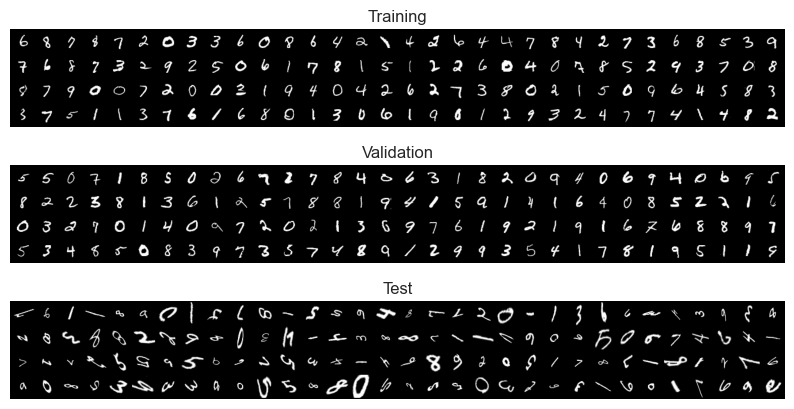

In [23]:
#plot images from transformed
vis_dataset(train_loader, val_loader, train_loader_transformed2)

In [26]:
#test model affine
energy_affine = create_ood_problem(
            detector_name="energy",
            params=get_default_ood_params("energy"),
            model=model_affine,
            train_cache=train_cache,
            transform_seq=transform_seq,
            dataset_info=dataset_info,
            architecture=architecture,
            device=str(device),
    )
load_or_run_evaluate_confidence_and_search(
            model=model_affine,
            optimizer=optimizer,
            problem=energy_affine,
            test_loader=test_loader_transformed,
            save_path=None,
            max_batch_override=dataset_info.batch_size_search,
            show_progress=True,
            repeats=1,
            return_per_run=True,
            overwrite=True,
            store_val=False,
            store_correct=True,
        )




Search eval:   0%|          | 0/39 [00:00<?, ?it/s]

Search eval:   0%|          | 0/39 [00:00<?, ?it/s, Acc=0.844, F2_mac=0.834, F2_mic=0.844, F2_w=0.843]

Search eval:   3%|▎         | 1/39 [00:00<00:06,  5.81it/s, Acc=0.844, F2_mac=0.834, F2_mic=0.844, F2_w=0.843]

Search eval:   3%|▎         | 1/39 [00:00<00:06,  5.81it/s, Acc=0.862, F2_mac=0.854, F2_mic=0.862, F2_w=0.861]

Search eval:   5%|▌         | 2/39 [00:00<00:06,  5.66it/s, Acc=0.862, F2_mac=0.854, F2_mic=0.862, F2_w=0.861]

Search eval:   5%|▌         | 2/39 [00:00<00:06,  5.66it/s, Acc=0.857, F2_mac=0.851, F2_mic=0.857, F2_w=0.855]

Search eval:   8%|▊         | 3/39 [00:00<00:06,  5.58it/s, Acc=0.857, F2_mac=0.851, F2_mic=0.857, F2_w=0.855]

Search eval:   8%|▊         | 3/39 [00:00<00:06,  5.58it/s, Acc=0.863, F2_mac=0.855, F2_mic=0.863, F2_w=0.861]

Search eval:  10%|█         | 4/39 [00:00<00:06,  5.61it/s, Acc=0.863, F2_mac=0.855, F2_mic=0.863, F2_w=0.861]

Search eval:  10%|█         | 4/39 [00:00<00:06,  5.61it/

{'repeats': 1,
 'accuracy_mean': 0.8500000238418579,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.8494353294372559,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.8500000238418579,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.8486021161079407,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.8500000238418579,
   'f2_macro': 0.8494353294372559,
   'f2_micro': 0.8500000238418579,
   'f2_weighted': 0.8486021161079407,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': [True,
    True,
    True,
    False,
    True,
    True,
    True,
    True,
    False,
    True,
    True,
    True,
    True,
    True,
    False,
    True,
    False,
    True,
    True,
    True,
    True,
    False,
    False,
    True,
    True,
    True,
    True,
    True,
    False,
    True,
    True,
    True,
    False,
  

In [29]:
from torch.utils.data import ConcatDataset
ds1 = dataset_train
ds2 = train_loader_transformed.dataset
concat= ConcatDataset([ds1, ds2])

loader_mixed = torch.utils.data.DataLoader(
    concat,
    batch_size=train_loader.batch_size,
    shuffle=True,
    num_workers=train_loader.num_workers,
    persistent_workers=train_loader.persistent_workers,
    pin_memory=True,
)

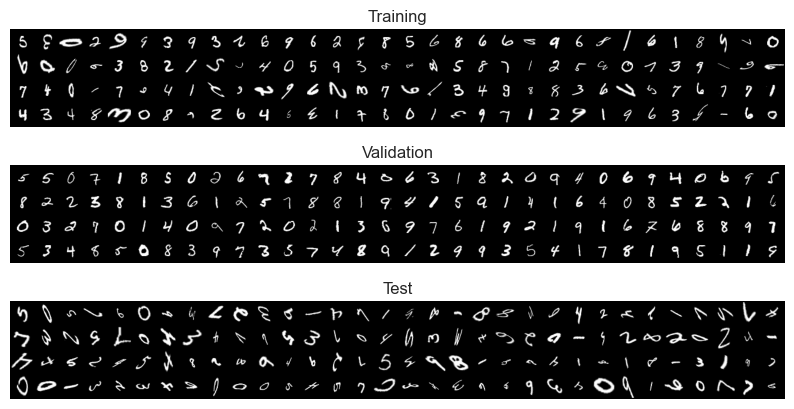

In [33]:
#visualze mixed loader
vis_dataset(loader_mixed, val_loader, test_loader_transformed)

In [38]:
model_mixed = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}_mixed"
train_and_get_model(model_mixed,model_dir_path,modelname, loader_mixed, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs//2,
        "precision": "16-mixed",
},load_if_exists=True)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_mixed.safetensors


(FlexibleResNet(
   (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
   (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (stem_act): GELU(approximate='none')
   (stages): ModuleList(
     (0): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (act): GELU(approximate='none')
       )
     )
     (1): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    

In [39]:
evaluate_base_model(model_mixed, test_loader, device)




BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s]

BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s, Acc=0.980, F2_mac=0.980, F2_mic=0.980, F2_w=0.980]

BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s, Acc=0.982, F2_mac=0.980, F2_mic=0.982, F2_w=0.982]

BaseModel eval:   5%|▌         | 2/40 [00:00<00:01, 19.52it/s, Acc=0.982, F2_mac=0.980, F2_mic=0.982, F2_w=0.982]

BaseModel eval:   5%|▌         | 2/40 [00:00<00:01, 19.52it/s, Acc=0.984, F2_mac=0.983, F2_mic=0.984, F2_w=0.984]

BaseModel eval:   5%|▌         | 2/40 [00:00<00:01, 19.52it/s, Acc=0.988, F2_mac=0.986, F2_mic=0.988, F2_w=0.987]

BaseModel eval:   5%|▌         | 2/40 [00:00<00:01, 19.52it/s, Acc=0.988, F2_mac=0.987, F2_mic=0.988, F2_w=0.988]

BaseModel eval:   5%|▌         | 2/40 [00:00<00:01, 19.52it/s, Acc=0.988, F2_mac=0.986, F2_mic=0.988, F2_w=0.988]

BaseModel eval:  15%|█▌        | 6/40 [00:00<00:01, 31.16it/s, Acc=0.988, F2_mac=0.986, F2_mic=0.988, F2_w=0.988]

BaseModel eval:  15%|█▌        | 6/40 

{'accuracy': 0.9923999905586243,
 'f2_macro': 0.9922481775283813,
 'f2_micro': 0.9923999905586243,
 'f2_weighted': 0.9923940896987915}

In [40]:
#test it
evaluate_base_model(model_mixed, test_loader_transformed, device)



BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s]

BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s, Acc=0.926, F2_mac=0.922, F2_mic=0.926, F2_w=0.925]

BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s, Acc=0.924, F2_mac=0.919, F2_mic=0.924, F2_w=0.924]

BaseModel eval:   5%|▌         | 2/40 [00:00<00:02, 15.63it/s, Acc=0.924, F2_mac=0.919, F2_mic=0.924, F2_w=0.924]

BaseModel eval:   5%|▌         | 2/40 [00:00<00:02, 15.63it/s, Acc=0.932, F2_mac=0.928, F2_mic=0.932, F2_w=0.931]

BaseModel eval:   5%|▌         | 2/40 [00:00<00:02, 15.63it/s, Acc=0.934, F2_mac=0.931, F2_mic=0.934, F2_w=0.934]

BaseModel eval:   5%|▌         | 2/40 [00:00<00:02, 15.63it/s, Acc=0.938, F2_mac=0.935, F2_mic=0.938, F2_w=0.937]

BaseModel eval:   5%|▌         | 2/40 [00:00<00:02, 15.63it/s, Acc=0.941, F2_mac=0.938, F2_mic=0.941, F2_w=0.941]

BaseModel eval:   5%|▌         | 2/40 [00:00<00:02, 15.63it/s, Acc=0.937, F2_mac=0.933, F2_mic=0.937, F2_w=0.936]

BaseModel eval:   5%|▌         | 2/40 

{'accuracy': 0.9351999759674072,
 'f2_macro': 0.9348517656326294,
 'f2_micro': 0.9351999759674072,
 'f2_weighted': 0.9350900650024414}

In [41]:
energy_mixed = create_ood_problem(
            detector_name="energy",
            params=get_default_ood_params("energy"),
            model=model_mixed,
            train_cache=train_cache,
            transform_seq=transform_seq,
            dataset_info=dataset_info,
            architecture=architecture,
            device=str(device),
    )
load_or_run_evaluate_confidence_and_search(
            model=model_mixed,
            optimizer=optimizer,
            problem=energy_mixed,
            test_loader=test_loader_transformed,
            save_path=None,
            max_batch_override=dataset_info.batch_size_search,
            show_progress=True,
            repeats=1,
            return_per_run=True,
            overwrite=True,
            store_val=False,
            store_correct=True,
        )



Search eval:   0%|          | 0/39 [00:00<?, ?it/s]

Search eval:   0%|          | 0/39 [00:00<?, ?it/s, Acc=0.969, F2_mac=0.968, F2_mic=0.969, F2_w=0.969]

Search eval:   3%|▎         | 1/39 [00:00<00:06,  5.77it/s, Acc=0.969, F2_mac=0.968, F2_mic=0.969, F2_w=0.969]

Search eval:   3%|▎         | 1/39 [00:00<00:06,  5.77it/s, Acc=0.966, F2_mac=0.965, F2_mic=0.966, F2_w=0.966]

Search eval:   5%|▌         | 2/39 [00:00<00:06,  5.64it/s, Acc=0.966, F2_mac=0.965, F2_mic=0.966, F2_w=0.966]

Search eval:   5%|▌         | 2/39 [00:00<00:06,  5.64it/s, Acc=0.969, F2_mac=0.967, F2_mic=0.969, F2_w=0.969]

Search eval:   8%|▊         | 3/39 [00:00<00:06,  5.50it/s, Acc=0.969, F2_mac=0.967, F2_mic=0.969, F2_w=0.969]

Search eval:   8%|▊         | 3/39 [00:00<00:06,  5.50it/s, Acc=0.972, F2_mac=0.970, F2_mic=0.972, F2_w=0.972]

Search eval:  10%|█         | 4/39 [00:00<00:06,  5.52it/s, Acc=0.972, F2_mac=0.970, F2_mic=0.972, F2_w=0.972]

Search eval:  10%|█         | 4/39 [00:00<00:06,  5.52it/

{'repeats': 1,
 'accuracy_mean': 0.9660000205039978,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.9659940004348755,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.9660000205039978,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.9658671617507935,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.9660000205039978,
   'f2_macro': 0.9659940004348755,
   'f2_micro': 0.9660000205039978,
   'f2_weighted': 0.9658671617507935,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': [True,
    True,
    True,
    True,
    True,
    True,
    True,
    True,
    True,
    True,
    True,
    True,
    True,
    True,
    True,
    True,
    False,
    True,
    True,
    True,
    True,
    True,
    False,
    True,
    True,
    True,
    True,
    True,
    True,
    True,
    True,
    True,
    True,
    True